# 전이학습(Transfer Learning)
- 참고 : https://cafe.daum.net/flowlife/S2Ul/32
- 성능이 좋은 모델을 만들고싶으나 내 시스템구축 환경이 부족할 때 모델을 그대로 받아서 사용 할 수 있게 끔
-  학습데이터가 부족한 분야의 모댈 구축을 위해 데이터가 풍푸한 분야에서 훈련된 모델을 재사용
<img src="https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Ft1.daumcdn.net%2Fcfile%2Ftistory%2F993FA34B5C5546CF12" width="300" height="200"/>

[이미지 참고 사이트](https://finewink.tistory.com/entry/%ED%95%99%EC%8A%B5%EB%8D%B0%EC%9D%B4%ED%84%B0-%EB%B6%80%EC%A1%B1%ED%98%84%EC%83%81-%ED%95%B4%EA%B2%B0%EB%B2%95-%EC%A0%84%EC%9D%B4%ED%95%99%EC%8A%B5Transfer-Learning)
- 한 작업(Source Domain)에서 학습된 모델을 관련 있는 다른 작업(Target Domain)에 적용하여, 적은 데이터와 자원으로도 높은 성능을 내는 딥러닝 기법
- 대규모 데이터로 사전 훈련된 모델(Pre-trained model)을 기반으로 **미세 조정(Fine-tuning)**하여 학습 속도와 정확도를 향상시키는 핵심적인 기술
## 핵심 특징 및 작동 원리
### 전이학습 (Transfer Learning)
- 개념 : 대규모 데이터셋(COCO, ImageNet 등)으로 이미 학습된 모델을 가져와서, 새로운 문제에 그대로 활
용하는 방법.
- 방식:
  - 기존 모델의 합성곱 계층(Feature Extractor)은 그대로 두고, 마지막 분류기(Classifier) 부분만 새로운
  데이터셋에 맞게 새로 학습.
- 장점: 데이터가 적을 때도 강력한 성능을 낼 수 있고, 학습 속도가 빠름.
    1) 모델 그대로 쓰기 (분류기만 사용)
    2) 모델 + 새로운 분류기만 학습
### 미세조정 (Fine-Tuning)
- 개념: 전이학습한 모델의 일부 또는 전부를 추가로 학습시켜서 새로운 데이터셋에 더 잘 맞추는 방법.
- 방식:
  - 일부 층만 “trainable”로 풀어서 재학습 (부분 미세조정)
  - 혹은 모델 전체를 새로운 데이터로 학습 (전체 미세조정)
- 장점: 기존 모델의 특징을 유지하면서도 새로운 데이터 특성에 맞게 조정 → 더 높은 성능 가능.
    3) 모델 + 일부 층 재학습
    4) 모델 전체 재학습
---
- Quadrant 1: Large + Different
  - 조건: 데이터셋이 크고, 사전학습 데이터와 다름.
  - 전략: 모델 전체를 다시 학습 (train the entire model).
  - 이유: 데이터가 충분히 크므로 처음부터 새로 학습해도 괜찮음.
- Quadrant 2: Large + Similar
  - 조건: 데이터셋이 크고, 사전학습 데이터와 유사함.
  - 전략: 일부 레이어만 학습, 나머지는 고정.
  - 이유: 특징이 이미 잘 학습돼 있으므로 전체를 다시 학습할 필요 없음.
- Quadrant 3: Small + Different
  - 조건: 데이터셋이 작고, 사전학습 데이터와 다름.
  - 전략: 일부 레이어만 학습, 나머지는 고정.
  - 이유: 데이터가 적으니 전체를 학습하면 과적합 위험 → 일부만 조정.
- Quadrant 4: Small + Similar
  - 조건: 데이터셋이 작고, 사전학습 데이터와 유사함.
  - 전략: 백본(Convolution base)을 동결, 새 출력층만 학습.
  - 이유: 이미 잘 맞는 특징을 갖고 있고, 데이터가 적으므로 최소 수정만

### MobileNet V2
- 대규모 이미지 데이터셋인 ImageNet데이터베이스를 기반으로 학습된 사전훈련모델(Pretained model)을 사용한다.
- 1000개의 클래스 : ImageNet데이터셋의 1000가지 물체 카테고리(개, 고양이, 자동차, 과일 등)를 분류할 때
- 사전 훈련된 모델 : 140만개 이상의 이미지를 사용하여 학습되었다.
- 학습된 대형모델(백본)인 MobileNet v2 그대로 cifat10  dataset 을 분류하기

In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt
(x_train, y_train),(x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalization
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# one hot
NUM_CLASESS = 10
y_train = tf.keras.utils.to_categorical(y_train, NUM_CLASESS)
y_test = tf.keras.utils.to_categorical(y_test, NUM_CLASESS)

print(f'train data : {x_train.shape}, {y_train.shape}') # (50000, 32, 32, 3), (50000, 10)
print(f'test data : {x_test.shape}, {y_test.shape}')    # (10000, 32, 32, 3), (10000, 10)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
train data : (50000, 32, 32, 3), (50000, 10)
test data : (10000, 32, 32, 3), (10000, 10)


In [10]:
# MobilNet v2 Model 불러오기
mobilenet_model = tf.keras.applications.MobileNetV2(
    input_shape = (32, 32, 3),  # cifar10 형태
    include_top = True,        # 기본 분류기 모두 포함.
    weights = None,             # None : model구조만 불러오기 - 모든 가중치는 random처리하겠다
    classes = NUM_CLASESS       # 원래 label은 천개, cifar10에 맞게 조정
)
print(mobilenet_model.summary())

Model: "mobilenetv2_1.00_32"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 16, 16,    │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 16, 16,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 16, 16,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 16, 16,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 16, 16,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 16, 16,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 16, 16,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 16, 16,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 16, 16,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 16, 16,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 16, 16,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 17, 17,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 8, 8, 96)  │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 8, 8, 96)  │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 8, 8, 96)  │          0 │ block_1_depthwis… │
│ (ReLU)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 8, 8, 24)  │      2,304 │ block_1_depthwis

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 2,236,682 (8.53 MB)

 Non-trainable params: 34,112 (133.25 KB)

None


In [11]:
mobilenet_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = mobilenet_model.fit(x_train, y_train, batch_size=64, epochs=10, validation_split=0.2, verbose=2)

loss , acc = mobilenet_model.evaluate(x_test, y_test, verbose=0)
print(f'mobilenet_model => loss :{loss:.4f}, acc :{acc:.4f}')

Epoch 1/10
625/625 - 83s - 132ms/step - accuracy: 0.2862 - loss: 1.9490 - val_accuracy: 0.0952 - val_loss: 2.3286
Epoch 2/10
625/625 - 30s - 48ms/step - accuracy: 0.4172 - loss: 1.5967 - val_accuracy: 0.1016 - val_loss: 2.3504
Epoch 3/10
625/625 - 10s - 16ms/step - accuracy: 0.4665 - loss: 1.4730 - val_accuracy: 0.0952 - val_loss: 2.3512
Epoch 4/10
625/625 - 9s - 15ms/step - accuracy: 0.5087 - loss: 1.3801 - val_accuracy: 0.1016 - val_loss: 2.3819
Epoch 5/10
625/625 - 9s - 15ms/step - accuracy: 0.5315 - loss: 1.3336 - val_accuracy: 0.1016 - val_loss: 2.3772
Epoch 6/10
625/625 - 9s - 15ms/step - accuracy: 0.5323 - loss: 1.3289 - val_accuracy: 0.1016 - val_loss: 2.3296
Epoch 7/10
625/625 - 9s - 15ms/step - accuracy: 0.5224 - loss: 1.3622 - val_accuracy: 0.1967 - val_loss: 2.1400
Epoch 8/10
625/625 - 9s - 15ms/step - accuracy: 0.5667 - loss: 1.2381 - val_accuracy: 0.3861 - val_loss: 1.8289
Epoch 9/10
625/625 - 9s - 15ms/step - accuracy: 0.5737 - loss: 1.2320 - val_accuracy: 0.1918 - val_l

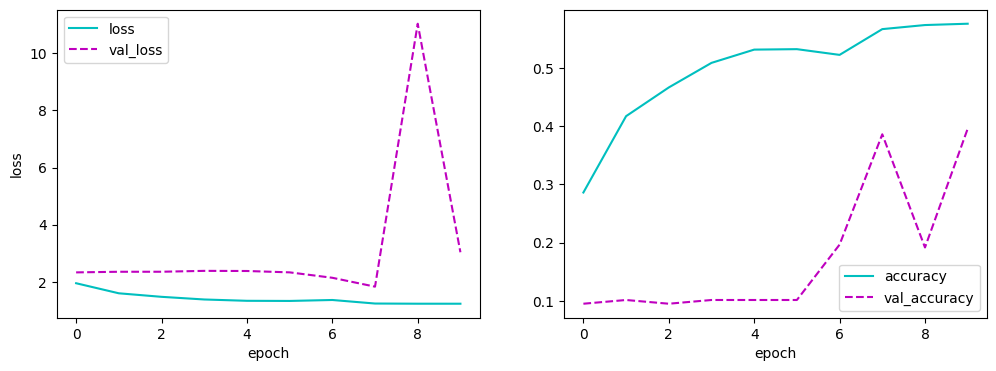

In [12]:
# 성능 시각화
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], 'c-', label='loss')
plt.plot(history.history['val_loss'], 'm--', label='val_loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], 'c-', label='accuracy')
plt.plot(history.history['val_accuracy'], 'm--', label='val_accuracy')
plt.xlabel('epoch')
plt.legend()
plt.show()